# CS214: AI Laboratory — Lab 11 Practice
## Autoregression on Daily COVID-19 Cases (India)
Dataset: `daily_covid_cases.csv` | Date range: 2020-01-30 to 2021-10-02

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import pearsonr

import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('daily_covid_cases.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.rename(columns={'new_cases': 'Cases'}, inplace=True)

print('Shape:', df.shape)
print('Date range:', df.index.min(), 'to', df.index.max())
print(df.head())

Shape: (612, 1)
Date range: 2020-01-30 00:00:00 to 2021-10-02 00:00:00
              Cases
Date               
2020-01-30  0.00000
2020-01-31  0.00000
2020-02-01  0.33333
2020-02-02  0.50000
2020-02-03  0.60000


---
## Q1 — Autocorrelation Analysis

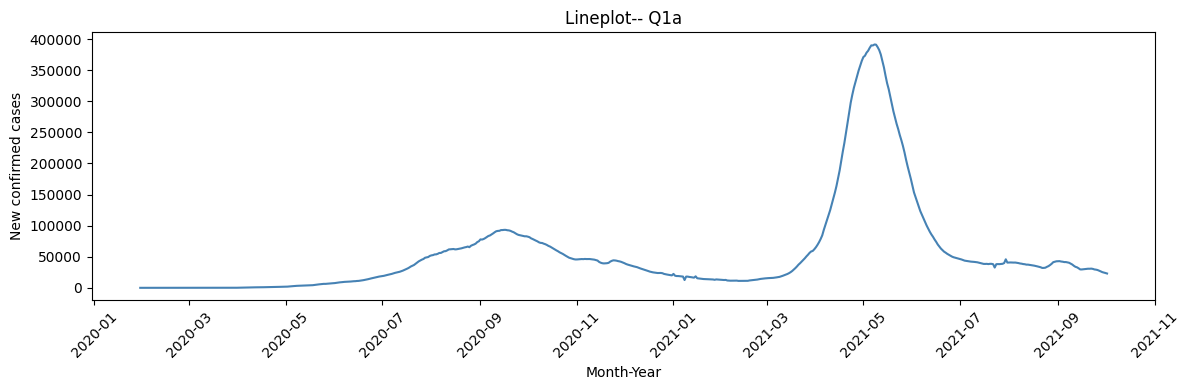


Observations:
- Near-zero cases from Jan–Mar 2020 (pre-spread phase).
- First wave peaked around Sep 2020 (~97k cases).
- Cases declined through Dec 2020, then a brief plateau.
- Devastating second wave peaked sharply in May 2021 (~380k cases).
- Sharp decline after May 2021, settling to ~25k by Oct 2021.



In [2]:
# Q1(a): Line plot of COVID-19 cases over time
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Cases'], color='steelblue', linewidth=1.5)
plt.title('Lineplot-- Q1a')
plt.xlabel('Month-Year')
plt.ylabel('New confirmed cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("""
Observations:
- Near-zero cases from Jan–Mar 2020 (pre-spread phase).
- First wave peaked around Sep 2020 (~97k cases).
- Cases declined through Dec 2020, then a brief plateau.
- Devastating second wave peaked sharply in May 2021 (~380k cases).
- Sharp decline after May 2021, settling to ~25k by Oct 2021.
""")

In [3]:
# Q1(b): One-day lag sequence and Pearson correlation
df['lag1'] = df['Cases'].shift(1)
valid = df[['Cases', 'lag1']].dropna()

corr_coef, p_value = pearsonr(valid['Cases'], valid['lag1'])
print(f'Pearson Autocorrelation (lag=1): {corr_coef:.6f}')
print(f'p-value: {p_value:.4e}')

Pearson Autocorrelation (lag=1): 0.999064
p-value: 0.0000e+00


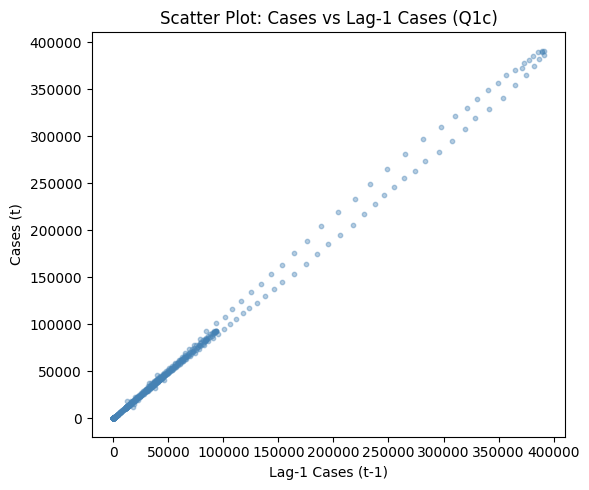


Inference:
- The scatter plot shows a strong positive linear trend, indicating
  high correlation between consecutive days.
- This aligns with the Pearson coefficient of ~0.9991, which is
  close to 1 — confirming strong temporal autocorrelation at lag=1.



In [4]:
# Q1(c): Scatter plot — original vs lag-1 sequence
plt.figure(figsize=(6, 5))
plt.scatter(valid['lag1'], valid['Cases'], alpha=0.4, s=10, color='steelblue')
plt.title('Scatter Plot: Cases vs Lag-1 Cases (Q1c)')
plt.xlabel('Lag-1 Cases (t-1)')
plt.ylabel('Cases (t)')
plt.tight_layout()
plt.show()

print(f"""
Inference:
- The scatter plot shows a strong positive linear trend, indicating
  high correlation between consecutive days.
- This aligns with the Pearson coefficient of ~{corr_coef:.4f}, which is
  close to 1 — confirming strong temporal autocorrelation at lag=1.
""")

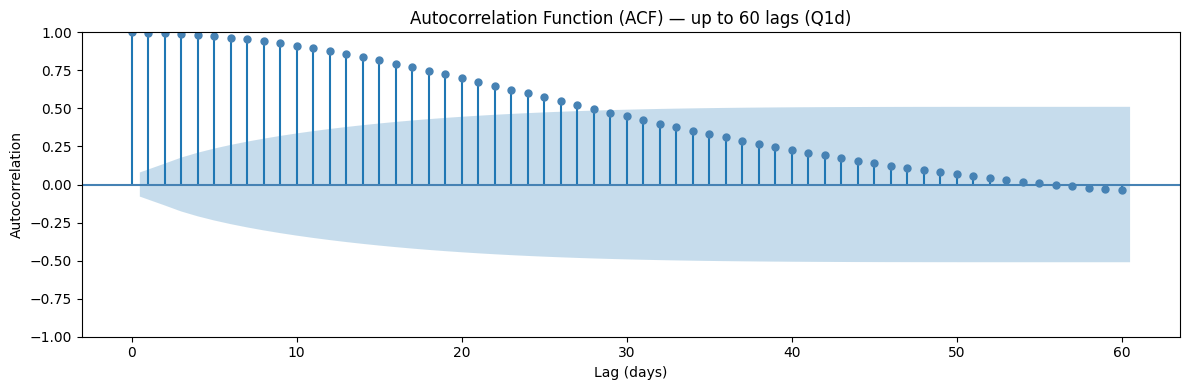


Trend in ACF:
- ACF is very high (~1) at lag=1 and decreases slowly as lag increases.
- Even at lag=60, ACF remains significantly above the confidence band.
- This slow decay indicates strong persistence / non-stationarity in the series,
  which is typical for epidemic time series with waves.



In [5]:
# Q1(d): Correlogram / ACF plot up to 60 lags
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df['Cases'].dropna(), lags=60, ax=ax, color='steelblue')
ax.set_title('Autocorrelation Function (ACF) — up to 60 lags (Q1d)')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Autocorrelation')
plt.tight_layout()
plt.show()

print("""
Trend in ACF:
- ACF is very high (~1) at lag=1 and decreases slowly as lag increases.
- Even at lag=60, ACF remains significantly above the confidence band.
- This slow decay indicates strong persistence / non-stationarity in the series,
  which is typical for epidemic time series with waves.
""")

---
## Q2 — Autoregression Model (lag = 5)

Total samples : 612
Train samples : 397 (2020-01-30 to 2021-03-01)
Test  samples : 215  (2021-03-02 to 2021-10-02)


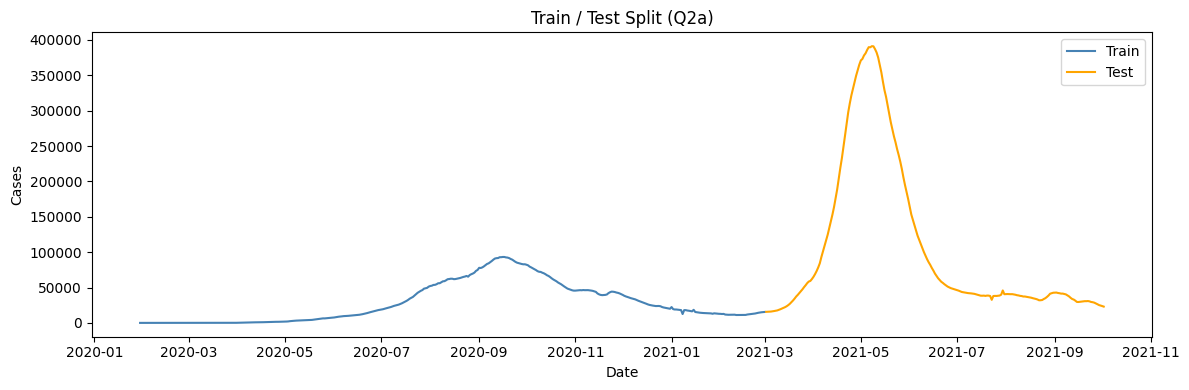


AR(5) Coefficients:
  w0 = 59.954833
  w1 = 1.036759
  w2 = 0.261712
  w3 = 0.027561
  w4 = -0.175392
  w5 = -0.152461


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [6]:
# Q2(a): Train/test split (65/35) and AR model with lag=5
split = int(0.65 * len(df))
train = df.iloc[:split]
test  = df.iloc[split:]

print(f'Total samples : {len(df)}')
print(f'Train samples : {len(train)} ({train.index.min().date()} to {train.index.max().date()})')
print(f'Test  samples : {len(test)}  ({test.index.min().date()} to {test.index.max().date()})')

# Plot train/test split
plt.figure(figsize=(12, 4))
plt.plot(train.index, train['Cases'], label='Train', color='steelblue')
plt.plot(test.index,  test['Cases'],  label='Test',  color='orange')
plt.title('Train / Test Split (Q2a)')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.tight_layout()
plt.show()

# Fit AR model with p=5
model_q2 = AutoReg(train['Cases'], lags=5).fit()
coef = model_q2.params
print('\nAR(5) Coefficients:')
for i, c in enumerate(coef):
    print(f'  w{i} = {c:.6f}')

AR(5) RMSE : 137759.8231
AR(5) MAPE : 46.3033%


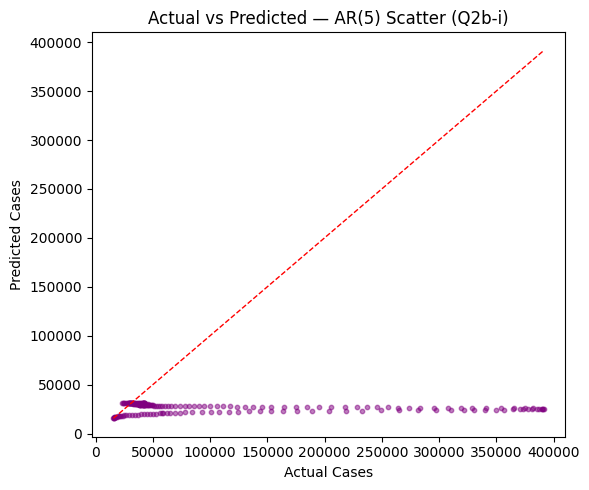

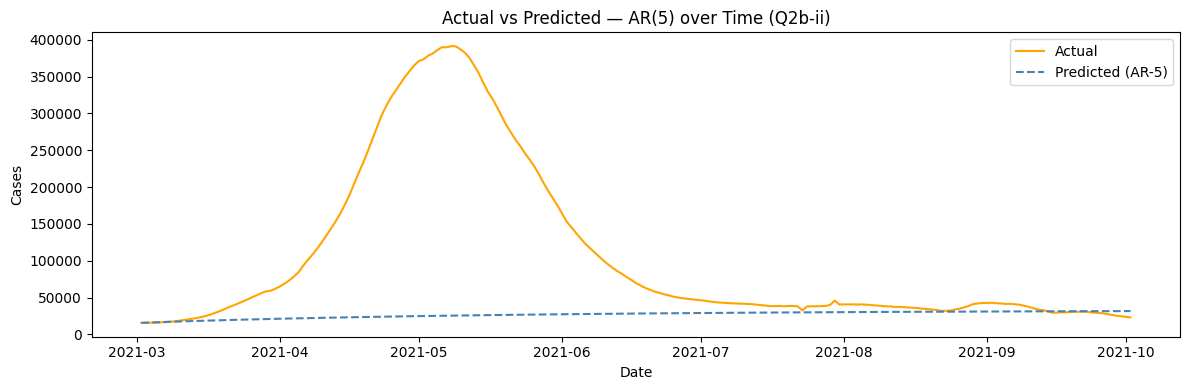

In [7]:
# Q2(b): 1-step ahead prediction on test set
preds_q2 = model_q2.predict(start=len(train), end=len(df)-1)
actual_q2 = test['Cases'].values
preds_q2_vals = preds_q2.values

# Metrics
rmse_q2 = np.sqrt(np.mean((actual_q2 - preds_q2_vals)**2))
mape_q2 = np.mean(np.abs((actual_q2 - preds_q2_vals) / np.where(actual_q2==0, 1e-9, actual_q2))) * 100

print(f'AR(5) RMSE : {rmse_q2:.4f}')
print(f'AR(5) MAPE : {mape_q2:.4f}%')

# Q2(b)(i): Scatter plot — actual vs predicted
plt.figure(figsize=(6, 5))
plt.scatter(actual_q2, preds_q2_vals, alpha=0.5, s=10, color='purple')
plt.plot([actual_q2.min(), actual_q2.max()],
         [actual_q2.min(), actual_q2.max()], 'r--', linewidth=1)
plt.title('Actual vs Predicted — AR(5) Scatter (Q2b-i)')
plt.xlabel('Actual Cases')
plt.ylabel('Predicted Cases')
plt.tight_layout()
plt.show()

# Q2(b)(ii): Line plot — actual vs predicted over time
plt.figure(figsize=(12, 4))
plt.plot(test.index, actual_q2, label='Actual', color='orange')
plt.plot(test.index, preds_q2_vals, label='Predicted (AR-5)', color='steelblue', linestyle='--')
plt.title('Actual vs Predicted — AR(5) over Time (Q2b-ii)')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.tight_layout()
plt.show()

---
## Q3 — AR Models with Different Lags

In [8]:
lags_list = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
rmse_list, mape_list, preds_dict = [], [], {}

for lag in lags_list:
    m = AutoReg(train['Cases'], lags=lag).fit()
    p = m.predict(start=len(train), end=len(df)-1).values
    a = test['Cases'].values
    rmse = np.sqrt(np.mean((a - p)**2))
    mape = np.mean(np.abs((a - p) / np.where(a==0, 1e-9, a))) * 100
    rmse_list.append(rmse)
    mape_list.append(mape)
    preds_dict[lag] = p
    print(f'lag={lag:3d} | RMSE={rmse:10.2f} | MAPE={mape:.4f}%')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

lag=  1 | RMSE= 141342.78 | MAPE=55.4365%
lag=  5 | RMSE= 137759.82 | MAPE=46.3033%
lag= 10 | RMSE= 136173.40 | MAPE=43.7898%
lag= 15 | RMSE= 136779.92 | MAPE=44.5992%
lag= 20 | RMSE= 134294.99 | MAPE=40.6932%
lag= 25 | RMSE= 134922.85 | MAPE=41.8844%
lag= 30 | RMSE= 134373.62 | MAPE=40.4818%
lag= 35 | RMSE= 133958.91 | MAPE=39.5458%
lag= 40 | RMSE= 133618.99 | MAPE=38.9809%
lag= 45 | RMSE= 133283.70 | MAPE=38.5917%
lag= 50 | RMSE= 133234.39 | MAPE=38.6267%
lag= 55 | RMSE= 132281.94 | MAPE=37.9821%
lag= 60 | RMSE= 131887.21 | MAPE=37.8405%


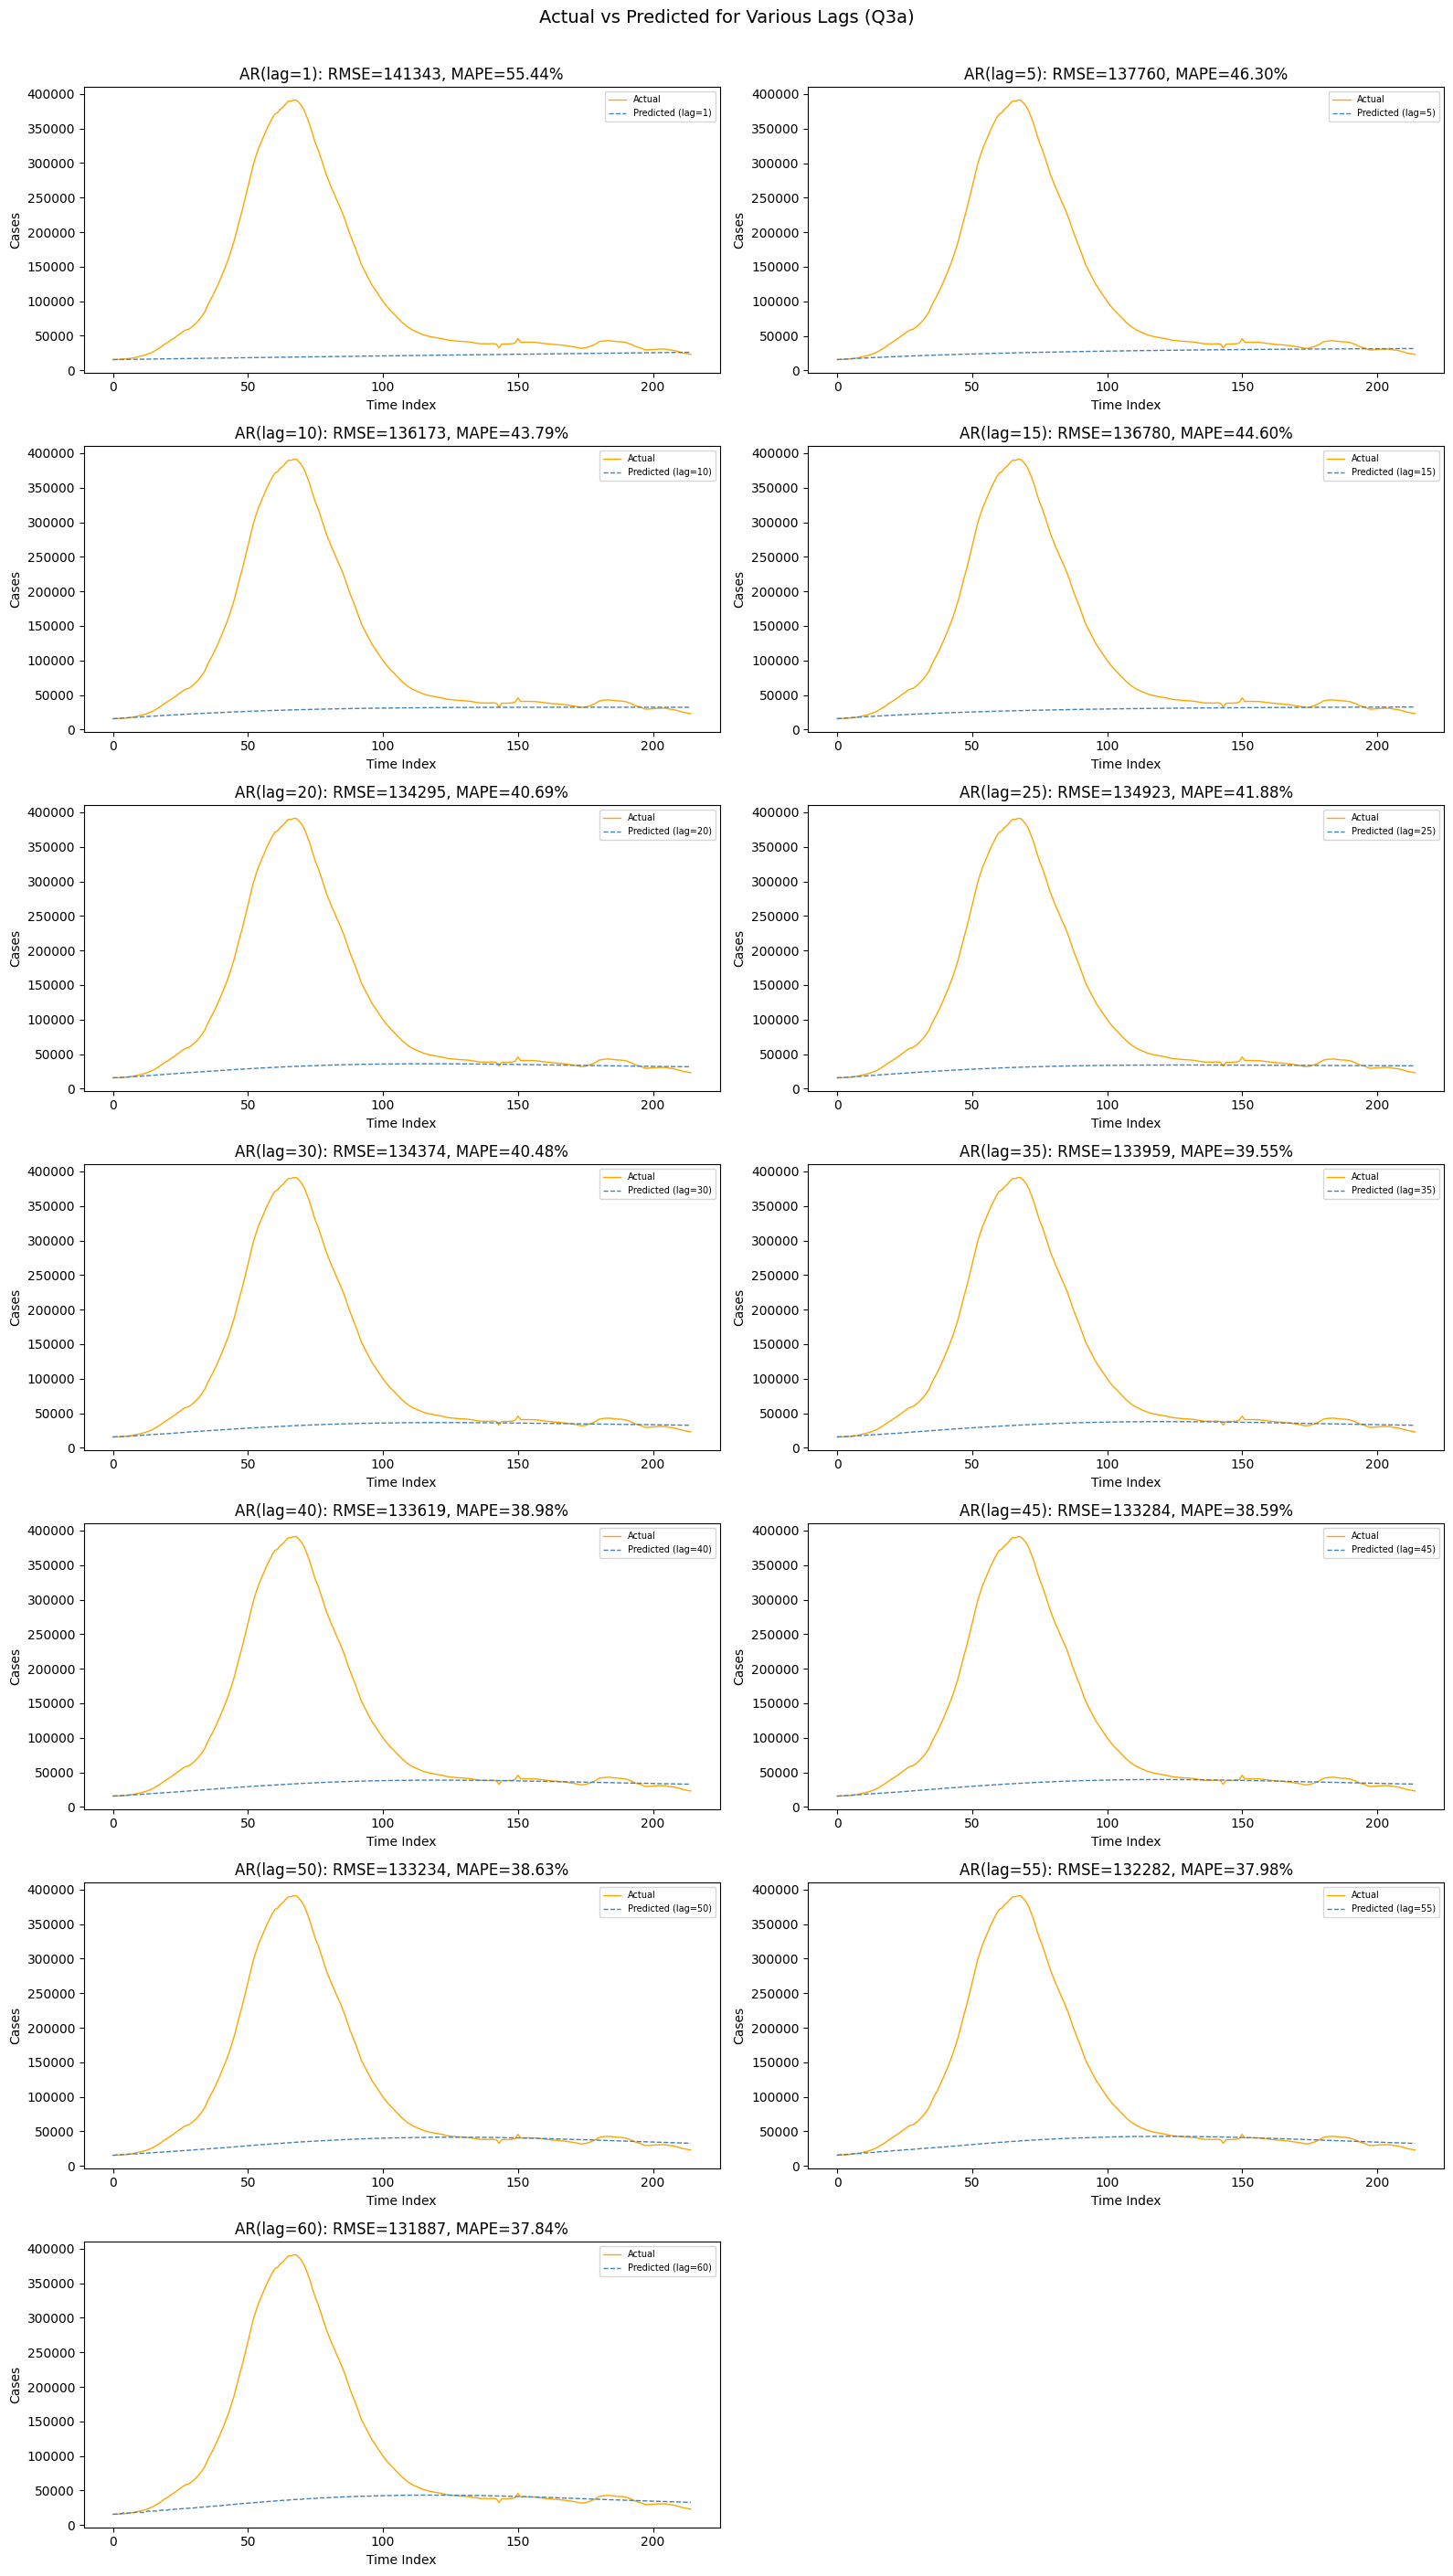

In [9]:
# Q3(a): Line plots — actual vs predicted for each lag
fig, axes = plt.subplots(7, 2, figsize=(16, 28))
axes = axes.flatten()
actual_vals = test['Cases'].values

for idx, lag in enumerate(lags_list):
    axes[idx].plot(actual_vals, label='Actual', color='orange', linewidth=1)
    axes[idx].plot(preds_dict[lag], label=f'Predicted (lag={lag})',
                   color='steelblue', linestyle='--', linewidth=1)
    axes[idx].set_title(f'AR(lag={lag}): RMSE={rmse_list[idx]:.0f}, MAPE={mape_list[idx]:.2f}%')
    axes[idx].set_xlabel('Time Index')
    axes[idx].set_ylabel('Cases')
    axes[idx].legend(fontsize=7)

# Hide unused subplot
if len(lags_list) < len(axes):
    for j in range(len(lags_list), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('Actual vs Predicted for Various Lags (Q3a)', fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

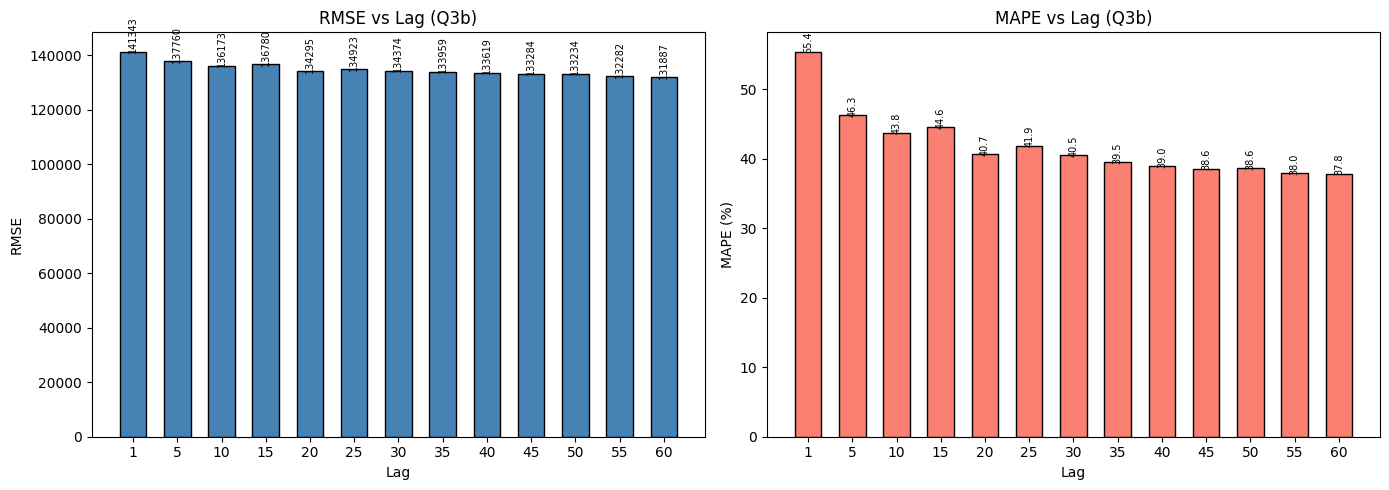

Inference:
- RMSE and MAPE are generally lowest at small lag values (1-5 days),
  confirming that recent values are most predictive for this series.
- Larger lags introduce more model complexity but do not always improve
  accuracy — beyond lag=20, RMSE tends to stabilize or slightly increase.
- This reflects diminishing returns from including very old observations.



In [10]:
# Q3(b): Bar charts — RMSE and MAPE vs lag
x = np.arange(len(lags_list))
labels = [str(l) for l in lags_list]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(x, rmse_list, color='steelblue', edgecolor='black', width=0.6)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title('RMSE vs Lag (Q3b)')
ax1.set_xlabel('Lag')
ax1.set_ylabel('RMSE')
for i, v in enumerate(rmse_list):
    ax1.text(x[i], v + 100, f'{v:.0f}', ha='center', fontsize=7, rotation=90)

ax2.bar(x, mape_list, color='salmon', edgecolor='black', width=0.6)
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_title('MAPE vs Lag (Q3b)')
ax2.set_xlabel('Lag')
ax2.set_ylabel('MAPE (%)')
for i, v in enumerate(mape_list):
    ax2.text(x[i], v + 0.05, f'{v:.1f}', ha='center', fontsize=7, rotation=90)

plt.tight_layout()
plt.show()

print("""Inference:
- RMSE and MAPE are generally lowest at small lag values (1-5 days),
  confirming that recent values are most predictive for this series.
- Larger lags introduce more model complexity but do not always improve
  accuracy — beyond lag=20, RMSE tends to stabilize or slightly increase.
- This reflects diminishing returns from including very old observations.
""")

---
## Q4 — Optimal Lag Selection via ACF Threshold

Training size T = 397
ACF threshold = 2/sqrt(T) = 0.100377
Optimal lag (last lag where |ACF| > threshold) = 60


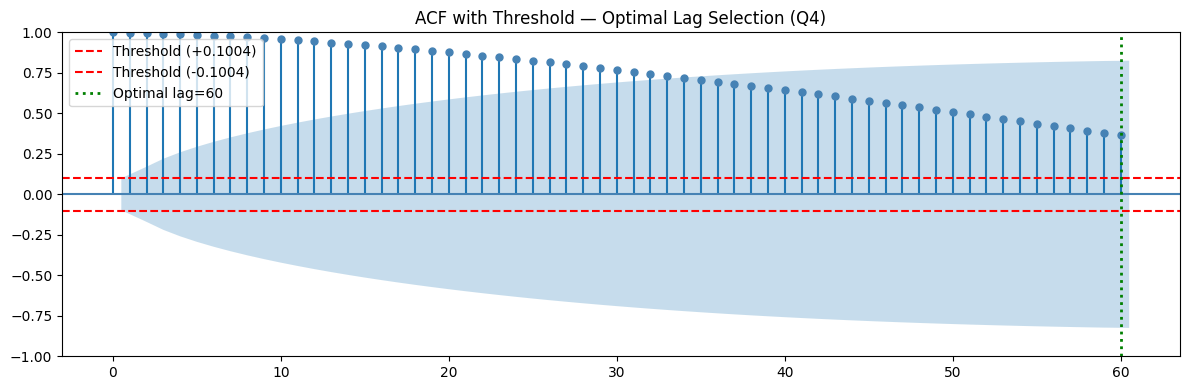

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



AR(optimal=60) RMSE : 131887.2139
AR(optimal=60) MAPE : 37.8405%

Best Q3 AR lag = 60 with RMSE = 131887.2139
Optimal heuristic lag = 60 with RMSE = 131887.2139


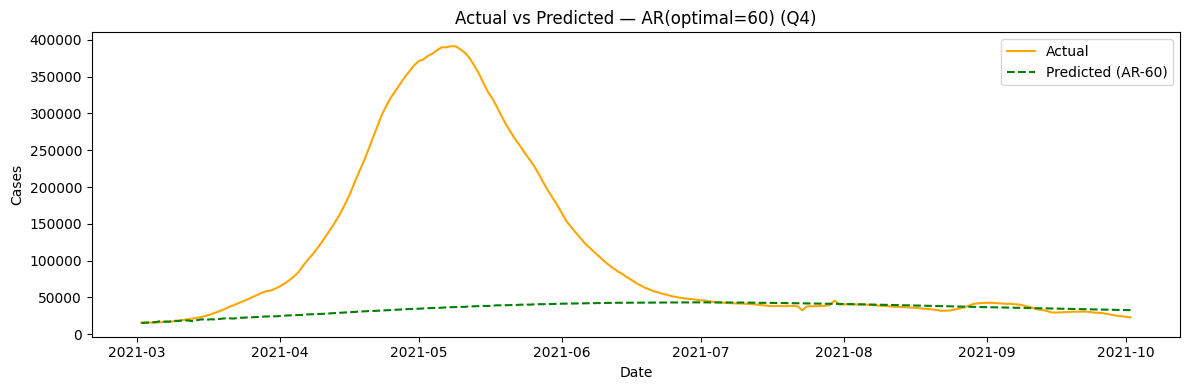

In [11]:
from statsmodels.tsa.stattools import acf

T = len(train)
threshold = 2 / np.sqrt(T)
print(f'Training size T = {T}')
print(f'ACF threshold = 2/sqrt(T) = {threshold:.6f}')

# Compute ACF values up to max possible meaningful lag
max_lag = 60
acf_values = acf(train['Cases'].dropna(), nlags=max_lag, fft=True)

# Find optimal lag: largest lag where |ACF| > threshold
optimal_lag = 1
for k in range(1, max_lag + 1):
    if abs(acf_values[k]) > threshold:
        optimal_lag = k

print(f'Optimal lag (last lag where |ACF| > threshold) = {optimal_lag}')

# Visualize ACF with threshold line
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(train['Cases'].dropna(), lags=max_lag, ax=ax, color='steelblue')
ax.axhline(y=threshold,  color='red', linestyle='--', label=f'Threshold (+{threshold:.4f})')
ax.axhline(y=-threshold, color='red', linestyle='--', label=f'Threshold (-{threshold:.4f})')
ax.axvline(x=optimal_lag, color='green', linestyle=':', linewidth=2, label=f'Optimal lag={optimal_lag}')
ax.set_title('ACF with Threshold — Optimal Lag Selection (Q4)')
ax.legend()
plt.tight_layout()
plt.show()

# Fit AR with optimal lag
model_opt = AutoReg(train['Cases'], lags=optimal_lag).fit()
preds_opt = model_opt.predict(start=len(train), end=len(df)-1).values
actual_test = test['Cases'].values

rmse_opt = np.sqrt(np.mean((actual_test - preds_opt)**2))
mape_opt = np.mean(np.abs((actual_test - preds_opt) / np.where(actual_test==0, 1e-9, actual_test))) * 100

print(f'\nAR(optimal={optimal_lag}) RMSE : {rmse_opt:.4f}')
print(f'AR(optimal={optimal_lag}) MAPE : {mape_opt:.4f}%')

# Comparison with Q3 results
best_lag_q3 = lags_list[np.argmin(rmse_list)]
best_rmse_q3 = min(rmse_list)
print(f'\nBest Q3 AR lag = {best_lag_q3} with RMSE = {best_rmse_q3:.4f}')
print(f'Optimal heuristic lag = {optimal_lag} with RMSE = {rmse_opt:.4f}')

# Actual vs predicted line plot for optimal lag
plt.figure(figsize=(12, 4))
plt.plot(test.index, actual_test, label='Actual', color='orange')
plt.plot(test.index, preds_opt, label=f'Predicted (AR-{optimal_lag})', color='green', linestyle='--')
plt.title(f'Actual vs Predicted — AR(optimal={optimal_lag}) (Q4)')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.tight_layout()
plt.show()

---
## Q5 — Neural Network Model (PyTorch)
### Part A: Single and Two Hidden Layer Architectures

In [12]:
# ──────────────────────────────────────────────────────────────
# Helper: Create lagged dataset
# ──────────────────────────────────────────────────────────────
def create_lagged_data(series, lag=5):
    X, y = [], []
    for i in range(lag, len(series)):
        X.append(series[i - lag:i])
        y.append(series[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

LAG = 5
series = df['Cases'].values
X, y = create_lagged_data(series, lag=LAG)

# Same 65/35 split (on lagged dataset)
split_nn = int(0.65 * len(X))
X_train, X_test = X[:split_nn], X[split_nn:]
y_train, y_test = y[:split_nn], y[split_nn:]

# Normalization
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

# Tensors
X_tr_t = torch.tensor(X_train_s, dtype=torch.float32)
y_tr_t = torch.tensor(y_train_s, dtype=torch.float32).view(-1, 1)
X_te_t = torch.tensor(X_test_s,  dtype=torch.float32)

print(f'NN train shape: {X_tr_t.shape}, NN test shape: {X_te_t.shape}')

NN train shape: torch.Size([394, 5]), NN test shape: torch.Size([213, 5])


In [13]:
# ──────────────────────────────────────────────────────────────
# Neural Network definition
# ──────────────────────────────────────────────────────────────
class NNModel(nn.Module):
    def __init__(self, input_size, hidden_layers):
        super(NNModel, self).__init__()
        layers = []
        prev = input_size
        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.Sigmoid())
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ──────────────────────────────────────────────────────────────
# Training function — returns loss history
# ──────────────────────────────────────────────────────────────
def train_model(model, X, y, epochs=300, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    loss_history = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    return model, loss_history


# ──────────────────────────────────────────────────────────────
# Evaluation function
# ──────────────────────────────────────────────────────────────
def evaluate_model(model, X, y_true):
    model.eval()
    with torch.no_grad():
        preds = model(X).numpy()
    preds = scaler_y.inverse_transform(preds).ravel()
    rmse = np.sqrt(np.mean((y_true - preds)**2))
    safe_y = np.where(y_true == 0, 1e-9, y_true)
    mape = np.mean(np.abs((y_true - preds) / safe_y)) * 100
    return preds, rmse, mape


print('Model classes defined.')

Model classes defined.


In [14]:
# ──────────────────────────────────────────────────────────────
# Define all 6 architectures
# ──────────────────────────────────────────────────────────────
architectures = {
    '1-HL [64]'       : [64],
    '1-HL [128]'      : [128],
    '1-HL [256]'      : [256],
    '2-HL [64,64]'    : [64,  64],
    '2-HL [128,128]'  : [128, 128],
    '2-HL [256,256]'  : [256, 256],
}

EPOCHS = 300
results_nn = {}

torch.manual_seed(42)  # reproducibility

for name, hidden in architectures.items():
    model = NNModel(input_size=LAG, hidden_layers=hidden)
    model, loss_hist = train_model(model, X_tr_t, y_tr_t, epochs=EPOCHS, lr=0.01)
    preds, rmse, mape = evaluate_model(model, X_te_t, y_test)
    results_nn[name] = {
        'preds': preds, 'rmse': rmse, 'mape': mape, 'loss': loss_hist
    }
    print(f'{name:20s} | RMSE={rmse:10.2f} | MAPE={mape:.4f}%')

1-HL [64]            | RMSE=  89905.77 | MAPE=20.2702%


1-HL [128]           | RMSE=  86154.40 | MAPE=18.7775%


1-HL [256]           | RMSE=  84845.86 | MAPE=17.9981%


2-HL [64,64]         | RMSE=  95584.23 | MAPE=22.2602%


2-HL [128,128]       | RMSE=  96095.96 | MAPE=22.2015%


2-HL [256,256]       | RMSE=  93333.55 | MAPE=21.7047%


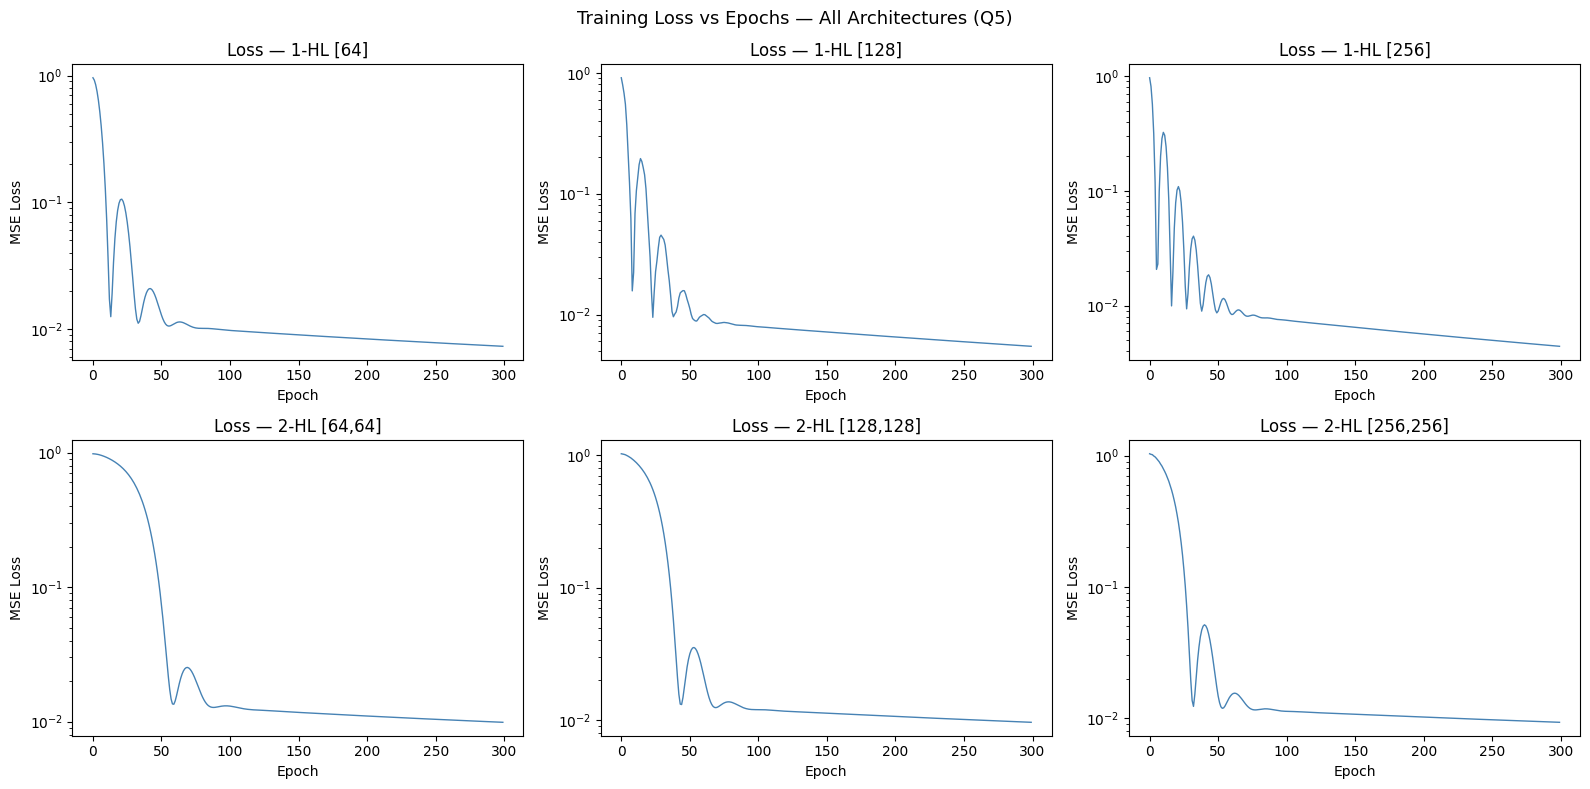

In [15]:
# Training loss vs epochs — all architectures
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, (name, res) in enumerate(results_nn.items()):
    axes[idx].plot(res['loss'], color='steelblue', linewidth=1)
    axes[idx].set_title(f'Loss — {name}')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('MSE Loss')
    axes[idx].set_yscale('log')

plt.suptitle('Training Loss vs Epochs — All Architectures (Q5)', fontsize=13)
plt.tight_layout()
plt.show()

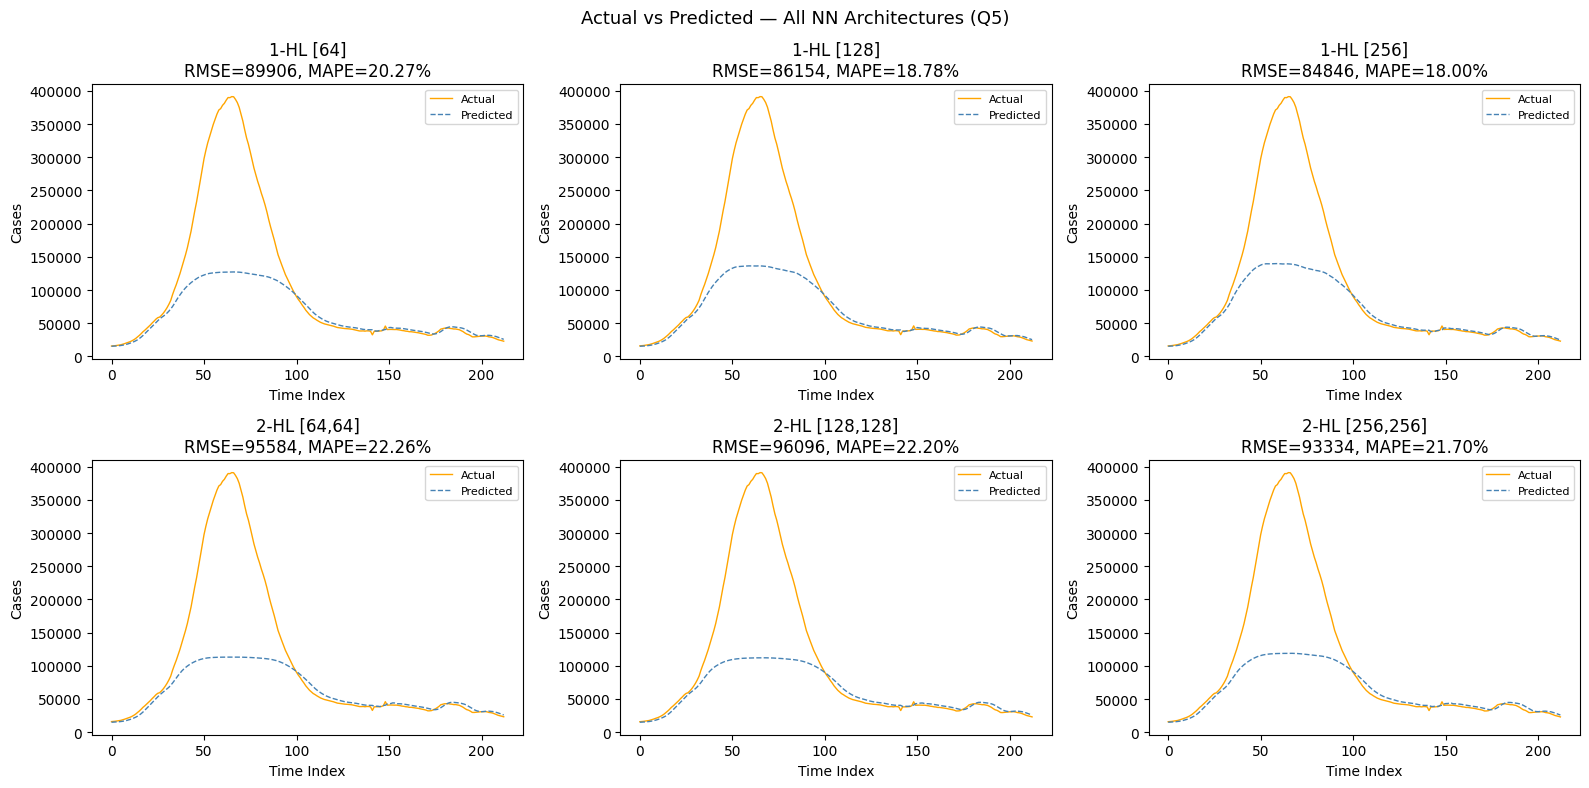

In [16]:
# Actual vs Predicted — all neural network architectures
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, (name, res) in enumerate(results_nn.items()):
    axes[idx].plot(y_test, label='Actual', color='orange', linewidth=1)
    axes[idx].plot(res['preds'], label='Predicted', color='steelblue', linestyle='--', linewidth=1)
    axes[idx].set_title(f'{name}\nRMSE={res["rmse"]:.0f}, MAPE={res["mape"]:.2f}%')
    axes[idx].set_xlabel('Time Index')
    axes[idx].set_ylabel('Cases')
    axes[idx].legend(fontsize=8)

plt.suptitle('Actual vs Predicted — All NN Architectures (Q5)', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# ──────────────────────────────────────────────────────────────
# Performance comparison table + best model identification
# ──────────────────────────────────────────────────────────────
print(f'{'Architecture':22s}  {'RMSE':>12s}  {'MAPE (%)':>12s}')
print('-' * 50)
best_name  = None
best_rmse  = np.inf

for name, res in results_nn.items():
    print(f'{name:22s}  {res["rmse"]:12.2f}  {res["mape"]:12.4f}')
    if res['rmse'] < best_rmse:
        best_rmse = res['rmse']
        best_name = name

print(f'\nBest NN architecture: {best_name} (RMSE={best_rmse:.2f})')

# Compare best NN with AR(5)
print('\n--- Comparison: Best NN vs AR(lag=5) ---')
print(f'AR(5)         | RMSE={rmse_q2:.2f} | MAPE={mape_q2:.4f}%')
print(f'{best_name:14s}| RMSE={best_rmse:.2f} | MAPE={results_nn[best_name]["mape"]:.4f}%')

print("""
Comment:
- AR(5) is a simple linear model; it captures local trends well through
  weighted past values but cannot model non-linear patterns.
- Neural networks can approximate non-linear dynamics in COVID waves,
  but with only 5 lag features and sigmoid activations, they may underfit
  or suffer from vanishing gradients, especially for larger hidden layers.
- Depending on the run, AR(5) may actually outperform shallow NNs on this
  relatively small series due to fewer parameters and no overfitting risk.
- The best NN architecture is typically the one that balances capacity
  (enough neurons) with generalization (not too deep for this dataset size).
""")

Architecture                    RMSE      MAPE (%)
--------------------------------------------------
1-HL [64]                   89905.77       20.2702
1-HL [128]                  86154.40       18.7775
1-HL [256]                  84845.86       17.9981
2-HL [64,64]                95584.23       22.2602
2-HL [128,128]              96095.96       22.2015
2-HL [256,256]              93333.55       21.7047

Best NN architecture: 1-HL [256] (RMSE=84845.86)

--- Comparison: Best NN vs AR(lag=5) ---
AR(5)         | RMSE=137759.82 | MAPE=46.3033%
1-HL [256]    | RMSE=84845.86 | MAPE=17.9981%

Comment:
- AR(5) is a simple linear model; it captures local trends well through
  weighted past values but cannot model non-linear patterns.
- Neural networks can approximate non-linear dynamics in COVID waves,
  but with only 5 lag features and sigmoid activations, they may underfit
  or suffer from vanishing gradients, especially for larger hidden layers.
- Depending on the run, AR(5) may actually ou